# Weighted TF-IDF Experiment

## Approach

Two separate sparse TF-IDF indexes were created for the title and text fields. TF-IDF retrieval was performed independently on both fields.

Since the raw scores from the two indexes can have different ranges, the scores were first normalized using Min-Max normalization:

$$
S_{norm}(d,q) =
\frac{S(d,q)-S_{min}(q)}
{S_{max}(q)-S_{min}(q)}
$$

The normalized scores were then combined using a weighted sum:

$$
S_{weighted}(d,q)
=
w_{title}S_{title,norm}(d,q)
+
w_{text}S_{text,norm}(d,q)
$$

where:

$$
w_{title}+w_{text}=1
$$

For example, with title weight = 0.27 and text weight = 0.73:

$$
S_{weighted}(d,q)
=
0.27S_{title,norm}(d,q)
+
0.73S_{text,norm}(d,q)
$$

This ensures that the title and text contributions are weighted fairly despite having different TF-IDF score ranges.

## Weight Tuning

Title weights from 0.10 to 0.30 were tested in increments of 0.01, with the remaining weight assigned to the text.

The best configuration was:

$$
\boxed{w_{title}=0.27,\quad w_{text}=0.73}
$$

## Results

| Model | MAP | MRR | P@5 | P@10 | nDCG@10 |
|---|---:|---:|---:|---:|---:|
| TF-IDF | 0.318897 | 0.554530 | 0.328889 | 0.236444 | 0.346963 |
| Weighted TF-IDF | 0.322927 | 0.577265 | 0.328889 | 0.245333 | 0.355195 |

## Finding

Weighted TF-IDF produced a modest improvement over the baseline TF-IDF model. The best configuration assigned 27% weight to the title and 73% to the text, indicating that the text field contributed more useful retrieval information while the title provided additional evidence.

The same preprocessing used in the previous experiment was retained.


Environment Setup

In [ ]:
%pip install -q python-terrier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pyterrier as pt
import pandas as pd
import re
import time

if not pt.started():
    pt.init()

print("PyTerrier version:", pt.__version__)

/tmp/ipykernel_3621/1066108698.py:6: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
PyTerrier version: 1.1.2


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_3621/1066108698.py:7: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


Obtain Cranfield collection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cran.tar.gz to cran.tar.gz


In [ ]:
import tarfile
with tarfile.open("cran.tar.gz", "r:gz") as cran:
  cran.extractall("cranfield")

/tmp/ipykernel_3621/1663252741.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  cran.extractall("cranfield")


Preprocessing of Documents

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving outliers_porter.py to outliers_porter.py
Saving outliers_preprocess.py to outliers_preprocess.py
Saving stopwords.txt to stopwords.txt


In [ ]:
import sys

sys.path.append("/content")

In [ ]:
from outliers_preprocess import (
    parse_documents,
    preprocess_text,
    load_stemmed_stopwords
)

from outliers_porter import PorterStemmer

In [ ]:
from pathlib import Path

input_path = Path("/content/cranfield/cran.all.1400")
stopwords_path = Path("/content/stopwords.txt")

In [ ]:
stemmer = PorterStemmer()
stemmed_stopwords = load_stemmed_stopwords(stopwords_path, stemmer)
documents = parse_documents(input_path)

In [ ]:
FIELD_TAGS = {".T", ".A", ".B", ".W"}
DOCUMENT_ID_RE = re.compile(r"\.I\s+(\d+)")

def parse_documents_by_field(path: Path):
    """Mirrors outliers_preprocess.parse_documents' section logic,
    but returns (doc_id, title_text, abstract_text) instead of merging them."""
    documents = []
    current_id = None
    section = None
    title_lines, abstract_lines = [], []

    with path.open(encoding="ascii") as source:
        for raw_line in source:
            line = raw_line.rstrip("\r\n")
            marker = line.strip()
            id_match = DOCUMENT_ID_RE.fullmatch(marker)

            if id_match:
                if current_id is not None:
                    documents.append((current_id, " ".join(title_lines), " ".join(abstract_lines)))
                current_id = int(id_match.group(1))
                section = None
                title_lines, abstract_lines = [], []
                continue

            if section == "abstract":
                if marker in FIELD_TAGS:
                    continue
                abstract_lines.append(line)
                continue

            if marker == ".T":
                section = "title"
            elif marker in {".A", ".B"}:
                section = "ignored"
            elif marker == ".W":
                section = "abstract"
            elif section == "title":
                title_lines.append(line)

    if current_id is not None:
        documents.append((current_id, " ".join(title_lines), " ".join(abstract_lines)))

    return documents

In [ ]:
input_path = Path("/content/cranfield/cran.all.1400")
raw_docs = parse_documents_by_field(input_path)

# sanity check before trusting the split
print("Sample doc 1 ->")
print("TITLE:", raw_docs[0][1][:100])
print("ABSTRACT:", raw_docs[0][2][:150])

processed_documents = []
for doc_id, title_text, abstract_text in raw_docs:
    title_tokens = preprocess_text(title_text, stemmer, stemmed_stopwords)
    abstract_tokens = preprocess_text(abstract_text, stemmer, stemmed_stopwords)

    processed_documents.append({
        "docno": str(doc_id),
        "title": " ".join(title_tokens),
        "text": " ".join(abstract_tokens)
    })

docs = pd.DataFrame(processed_documents)
docs.head()

Sample doc 1 ->
TITLE: experimental investigation of the aerodynamics of a wing in a slipstream .
ABSTRACT: experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in ord


,docno,title,text
0,1,experiment investig aerodynam wing slipstream,experiment investig aerodynam wing slipstream ...
1,2,simpl shear flow past flat plate incompress fl...,simpl shear flow past flat plate incompress fl...
2,3,boundari layer simpl shear flow past flat plate,boundari layer simpl shear flow past flat plat...
3,4,approxim solut incompress laminar boundari lay...,approxim solut incompress laminar boundari lay...
4,5,dimension transient heat conduct doubl layer s...,dimension transient heat conduct doubl layer s...


Preprocessing of Queries

In [ ]:
def parse_queries(file_path):

    queries = []

    with open(file_path, "r", encoding="ascii", errors="ignore") as f:
        lines = f.readlines()

    current_query = []
    in_query = False

    for line in lines:

        line = line.rstrip("\n")

        # Start of a new query block
        if re.match(r"\.I\s+\d+", line):

            # Save previous query
            if current_query:
                queries.append({
                    "qid": str(len(queries) + 1),
                    "query": " ".join(current_query).strip()
                })

            current_query = []
            in_query = False

        elif line.strip() == ".W":

            in_query = True

        elif in_query:

            current_query.append(line.strip())

    # Save last query
    if current_query:
        queries.append({
            "qid": str(len(queries) + 1),
            "query": " ".join(current_query).strip()
        })

    return pd.DataFrame(queries)

In [ ]:
query = parse_queries("/content/cranfield/cran.qry")

In [ ]:
processed_queries = []

for _, row in query.iterrows():

    tokens = preprocess_text(row["query"],stemmer,stemmed_stopwords)

    processed_queries.append({
        "qid": str(row["qid"]),
        "query": " ".join(tokens)
    })

query = pd.DataFrame(processed_queries)

In [ ]:
display(query.head(10))

,qid,query
0,1,similar law obey construct aeroelast model hea...
1,2,structur aeroelast problem associ flight high ...
2,3,problem heat conduct composit slab solv far
3,4,criterion develop empir valid flow solut chemi...
4,5,chemic kinet applic hyperson aerodynam problem
5,6,theoret experiment guid turbul couett flow beh...
6,7,possibl relat avail pressur distribut ogiv for...
7,8,method dash exact approxim dash present avail ...
8,9,paper intern slip flow heat transfer studi
9,10,real ga transport properti air avail wide rang...


Indexing for text

In [ ]:
index_path = "/content/cranfield_tfidf_index"

indexer_text = pt.index.IterDictIndexer(
    index_path,
    meta=["docno"],
    text_attrs=["text"],
    overwrite=True
)

In [ ]:
start_time = time.perf_counter()

indexref_text = indexer_text.index(
    docs.to_dict("records")
)

index_time = time.perf_counter() - start_time

print(f"Indexing time: {index_time:.4f} seconds")

13:44:29.482 [ForkJoinPool-4-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (471) - further warnings are suppressed
13:44:30.277 [ForkJoinPool-4-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2 empty documents
Indexing time: 1.1588 seconds


In [ ]:
index_text = pt.IndexFactory.of(indexref_text)

In [ ]:
print(index_text.getCollectionStatistics())

Number of documents: 1400
Number of terms: 4389
Number of postings: 77353
Number of fields: 0
Number of tokens: 121177
Field names: []
Positions:   false



In [ ]:
print(index_text.getLexicon())

<org.terrier.structures.Lexicon at 0x7db269716940 jclass=org/terrier/structures/Lexicon jself=<LocalRef obj=0x224fd44a at 0x7db269bcbfd0>>


In [ ]:
lexicon = index_text.getLexicon()

terms = []

for entry in lexicon:
    terms.append(entry.getKey())

print("First 100 indexed terms:")
print(terms[300:350])

First 100 indexed terms:
['87', '88', '897', '899', '9', '90', '900', '9000', '91', '92', '94', '944', '95', '952', '954', '96', '962', '97', '979', '98', '981', '99', 'ab', 'abbrevi', 'abil', 'abl', 'ablat', 'abrupt', 'abruptli', 'absenc', 'absent', 'absolut', 'absorb', 'absorpt', 'abstract', 'abundantli', 'academ', 'accel', 'acceleromet', 'accentu', 'accept', 'access', 'accid', 'accommod', 'accompani', 'accomplish', 'accord', 'accordingli', 'account', 'accru']


In [ ]:
term = "aircraft"

lexicon = index_text.getLexicon()
entry = lexicon.getLexiconEntry(term)

if entry is None:
    print(f"'{term}' not found in index")
else:
    print("Term:", term)
    print("Document frequency:", entry.getDocumentFrequency())
    print("Collection frequency:", entry.getFrequency())

    postings = index_text.getInvertedIndex().getPostings(entry)

    print("\nPosting list:")
    for posting in postings:
        print(
            "docid =", posting.getId(),
            "tf =", posting.getFrequency()
        )

Term: aircraft
Document frequency: 71
Collection frequency: 131

Posting list:
docid = 11 tf = 2
docid = 13 tf = 1
docid = 28 tf = 2
docid = 46 tf = 2
docid = 50 tf = 9
docid = 74 tf = 1
docid = 75 tf = 1
docid = 77 tf = 2
docid = 99 tf = 6
docid = 171 tf = 1
docid = 183 tf = 1
docid = 194 tf = 1
docid = 201 tf = 3
docid = 208 tf = 1
docid = 219 tf = 1
docid = 236 tf = 1
docid = 244 tf = 1
docid = 250 tf = 1
docid = 252 tf = 5
docid = 310 tf = 1
docid = 327 tf = 1
docid = 344 tf = 1
docid = 363 tf = 1
docid = 373 tf = 1
docid = 414 tf = 2
docid = 415 tf = 1
docid = 452 tf = 2
docid = 496 tf = 2
docid = 657 tf = 1
docid = 720 tf = 1
docid = 723 tf = 1
docid = 724 tf = 2
docid = 725 tf = 1
docid = 728 tf = 1
docid = 746 tf = 1
docid = 790 tf = 1
docid = 791 tf = 5
docid = 803 tf = 1
docid = 809 tf = 1
docid = 810 tf = 4
docid = 835 tf = 1
docid = 877 tf = 1
docid = 881 tf = 1
docid = 882 tf = 2
docid = 883 tf = 3
docid = 907 tf = 1
docid = 908 tf = 1
docid = 910 tf = 1
docid = 913 tf = 1

Indexing for Title

In [ ]:
index_path = "/content/cranfield_tfidf_index"

indexer_title = pt.index.IterDictIndexer(
    index_path,
    meta=["docno"],
    text_attrs=["title"],
    overwrite=True
)

In [ ]:
start_time = time.perf_counter()

indexref_title = indexer_title.index(
    docs.to_dict("records")
)

index_time = time.perf_counter() - start_time

print(f"Indexing time: {index_time:.4f} seconds")

13:44:58.637 [ForkJoinPool-5-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (471) - further warnings are suppressed
13:44:59.278 [ForkJoinPool-5-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2 empty documents
Indexing time: 0.8867 seconds


In [ ]:
index_title = pt.IndexFactory.of(indexref_title)

In [ ]:
print(index_title.getCollectionStatistics())

Number of documents: 1400
Number of terms: 1242
Number of postings: 10857
Number of fields: 0
Number of tokens: 11004
Field names: []
Positions:   false



TF_IDF

In [ ]:
tfidf_title = pt.terrier.Retriever(
    index_title,
    wmodel="TF_IDF"
)

In [ ]:
tfidf_text = pt.terrier.Retriever(
    index_text,
    wmodel="TF_IDF"
)

In [ ]:
start = time.perf_counter()

title_results = tfidf_title.transform(query)
text_results = tfidf_text.transform(query)

search_time = time.perf_counter() - start

print(f"Search time: {search_time:.4f} seconds")

Search time: 10.3691 seconds


In [ ]:
print(title_results.head())
print(text_results.head())

  qid                                              query  docid docno  rank  \
0   1  similar law obey construct aeroelast model hea...     12    13     0   
1   1  similar law obey construct aeroelast model hea...    874   875     1   
2   1  similar law obey construct aeroelast model hea...    745   746     2   
3   1  similar law obey construct aeroelast model hea...    791   792     3   
4   1  similar law obey construct aeroelast model hea...    485   486     4   

       score  
0  10.798385  
1   9.943278  
2   9.905317  
3   9.217246  
4   9.120933  
  qid                                              query  docid docno  rank  \
0   1  similar law obey construct aeroelast model hea...     50    51     0   
1   1  similar law obey construct aeroelast model hea...    485   486     1   
2   1  similar law obey construct aeroelast model hea...     11    12     2   
3   1  similar law obey construct aeroelast model hea...    183   184     3   
4   1  similar law obey construct aeroel

In [ ]:
def minmax_normalize(group):
    min_score = group["score"].min()
    max_score = group["score"].max()

    if max_score == min_score:
        group["score"] = 0.0
    else:
        group["score"] = (
            (group["score"] - min_score)
            / (max_score - min_score)
        )

    return group

In [ ]:
title_results_norm = (
    title_results
    .groupby("qid", group_keys=False)
    .apply(minmax_normalize)
    .reset_index(drop=True)
)

text_results_norm = (
    text_results
    .groupby("qid", group_keys=False)
    .apply(minmax_normalize)
    .reset_index(drop=True)
)

/tmp/ipykernel_3621/3261272505.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)
/tmp/ipykernel_3621/3261272505.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)


In [ ]:
print(title_results_norm.head())
print(text_results_norm.head())

  qid                                              query  docid docno  rank  \
0   1  similar law obey construct aeroelast model hea...     12    13     0   
1   1  similar law obey construct aeroelast model hea...    874   875     1   
2   1  similar law obey construct aeroelast model hea...    745   746     2   
3   1  similar law obey construct aeroelast model hea...    791   792     3   
4   1  similar law obey construct aeroelast model hea...    485   486     4   

      score  
0  1.000000  
1  0.910234  
2  0.906249  
3  0.834018  
4  0.823907  
  qid                                              query  docid docno  rank  \
0   1  similar law obey construct aeroelast model hea...     50    51     0   
1   1  similar law obey construct aeroelast model hea...    485   486     1   
2   1  similar law obey construct aeroelast model hea...     11    12     2   
3   1  similar law obey construct aeroelast model hea...    183   184     3   
4   1  similar law obey construct aeroelast mo

In [ ]:
title_results_norm = title_results_norm.rename(
    columns={"score": "title_score"}
)

text_results_norm = text_results_norm.rename(
    columns={"score": "text_score"}
)


In [ ]:
title_results_norm = title_results_norm[
    ["qid", "docno", "title_score"]
]

text_results_norm = text_results_norm[
    ["qid", "docno", "text_score"]
]

In [ ]:
combined = title_results_norm.merge(
    text_results_norm,
    on=["qid", "docno"],
    how="outer"
)

In [ ]:
combined["title_score"] = combined["title_score"].fillna(0)
combined["text_score"] = combined["text_score"].fillna(0)

In [ ]:
title_weight = 0.7
text_weight = 0.3

combined["score"] = (
    title_weight * combined["title_score"]
    + text_weight * combined["text_score"]
)

In [ ]:
combined = combined.sort_values(
    ["qid", "score"],
    ascending=[True, False]
)

In [ ]:
combined["rank"] = (
    combined
    .groupby("qid")
    .cumcount()
)

In [ ]:
final_results = combined[
    ["qid", "docno", "score", "rank"]
]

In [ ]:
print(final_results.head(20))

    qid docno     score  rank
490   1   486  0.858452     0
188   1    13  0.851175     1
677   1   746  0.801700     2
285   1   184  0.779559     3
506   1    51  0.764554     4
744   1   875  0.752916     5
701   1   792  0.702613     6
415   1   359  0.626506     7
460   1   435  0.578310     8
218   1  1340  0.572637     9
678   1   747  0.529966    10
116   1    12  0.526882    11
748   1   879  0.484844    12
565   1   584  0.476185    13
384   1   315  0.475466    14
582   1   606  0.474869    15
539   1    56  0.462501    16
341   1   252  0.459512    17
75    1  1144  0.455596    18
76    1  1147  0.452390    19


Evaluation

In [ ]:
qrels = pd.read_csv(
    "/content/cranfield/cranqrel",
    sep=r"\s+",
    header=None,
    names=["qid", "docno", "label"]
)

qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)

print(qrels.head())
print("Number of relevance judgments:", len(qrels))
print("Number of queries:", qrels["qid"].nunique())

  qid docno  label
0   1   184      2
1   1    29      2
2   1    31      2
3   1    12      3
4   1    51      3
Number of relevance judgments: 1837
Number of queries: 225


In [ ]:
print("TF-IDF columns:")
print(final_results.columns.tolist())

print("\nQrels columns:")
print(qrels.columns.tolist())

TF-IDF columns:
['qid', 'docno', 'score', 'rank']

Qrels columns:
['qid', 'docno', 'label']


In [ ]:
print(final_results[["qid", "docno"]].dtypes)
print(qrels[["qid", "docno"]].dtypes)

qid      object
docno    object
dtype: object
qid      object
docno    object
dtype: object


In [ ]:
tfidf_eval = pt.Evaluate(
    final_results,
    qrels,
    metrics=[
        "map",
        "recip_rank",
        "P.5",
        "P.10",
        "ndcg_cut.10"
    ]
)

In [ ]:
tfidf_results_table = pd.DataFrame([{
    "Model": "TF-IDF",
    "MAP": tfidf_eval["map"],
    "MRR": tfidf_eval["recip_rank"],
    "P@5": tfidf_eval["P.5"],
    "P@10": tfidf_eval["P.10"],
    "nDCG@10": tfidf_eval["ndcg_cut.10"],
    "Index Time (s)": index_time,
    "Search Time (s)": search_time
}])

tfidf_results_table

,Model,MAP,MRR,P@5,P@10,nDCG@10,Index Time (s),Search Time (s)
0,TF-IDF,0.280501,0.517941,0.299556,0.216444,0.307429,0.886668,10.369092


Trying with different weights

In [ ]:
def weighted_tfidf(
    queries,
    title_tfidf,
    text_tfidf,
    title_weight,
    text_weight
):
    # Retrieve from title and text
    title_results = title_tfidf.transform(queries)
    text_results = text_tfidf.transform(queries)

    # Normalize within each query
    title_results = (
        title_results
        .groupby("qid", group_keys=False)
        .apply(minmax_normalize)
        .reset_index(drop=True)
    )

    text_results = (
        text_results
        .groupby("qid", group_keys=False)
        .apply(minmax_normalize)
        .reset_index(drop=True)
    )

    # Rename scores
    title_results = title_results.rename(
        columns={"score": "title_score"}
    )[["qid", "docno", "title_score"]]

    text_results = text_results.rename(
        columns={"score": "text_score"}
    )[["qid", "docno", "text_score"]]

    # Merge
    combined = title_results.merge(
        text_results,
        on=["qid", "docno"],
        how="outer"
    )

    combined["title_score"] = combined["title_score"].fillna(0)
    combined["text_score"] = combined["text_score"].fillna(0)

    # Weighted combination
    combined["score"] = (
        title_weight * combined["title_score"]
        + text_weight * combined["text_score"]
    )

    # Ranking
    combined = combined.sort_values(
        ["qid", "score"],
        ascending=[True, False]
    )

    combined["rank"] = (
        combined
        .groupby("qid")
        .cumcount()
    )

    return combined[
        ["qid", "docno", "score", "rank"]
    ]


In [ ]:
weights = [
    (0.0, 1.0),
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
    (1.0, 0.0)
]


all_results = {}
evaluation_results = []

for title_w, text_w in weights:

    # Weighted TF-IDF retrieval
    results = weighted_tfidf(
        query,
        tfidf_title,
        tfidf_text,
        title_weight=title_w,
        text_weight=text_w
    )

    # Store retrieval results
    all_results[(title_w, text_w)] = results

    # Evaluate
    eval_result = pt.Evaluate(
        results,
        qrels,
        metrics=[
            "map",
            "recip_rank",
            "P.5",
            "P.10",
            "ndcg_cut.10"
        ]
    )

    # Add weights + evaluation results
    evaluation_results.append({
        "Title Weight": title_w,
        "Text Weight": text_w,
        "MAP": eval_result["map"],
        "MRR": eval_result["recip_rank"],
        "P@5": eval_result["P.5"],
        "P@10": eval_result["P.10"],
        "nDCG@10": eval_result["ndcg_cut.10"]
    })

# Convert to table
evaluation_table = pd.DataFrame(evaluation_results)

print(evaluation_table)

/tmp/ipykernel_3621/2292238955.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)
/tmp/ipykernel_3621/2292238955.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)
/tmp/ipykernel_3621/2292238955.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

    Title Weight  Text Weight       MAP       MRR       P@5      P@10  \
0            0.0          1.0  0.307162  0.547880  0.316444  0.233778   
1            0.1          0.9  0.317432  0.564249  0.328889  0.240000   
2            0.2          0.8  0.322462  0.573912  0.329778  0.241778   
3            0.3          0.7  0.320951  0.569118  0.329778  0.246667   
4            0.4          0.6  0.317497  0.559427  0.320889  0.245778   
5            0.5          0.5  0.304073  0.534502  0.313778  0.236889   
6            0.6          0.4  0.293569  0.525183  0.304000  0.227556   
7            0.7          0.3  0.280501  0.517941  0.299556  0.216444   
8            0.8          0.2  0.269285  0.511535  0.289778  0.208889   
9            0.9          0.1  0.256986  0.498140  0.271111  0.204889   
10           1.0          0.0  0.243821  0.484988  0.256889  0.190667   

     nDCG@10  
0   0.337308  
1   0.348278  
2   0.351586  
3   0.354416  
4   0.350314  
5   0.334606  
6   0.322665  
7  

Trying with sweet spot of 20-30%

In [ ]:
weights = [
    (0.10, 0.90),
    (0.11, 0.89),
    (0.12, 0.88),
    (0.13, 0.87),
    (0.14, 0.86),
    (0.15, 0.85),
    (0.16, 0.84),
    (0.17, 0.83),
    (0.18, 0.82),
    (0.19, 0.81),
    (0.20, 0.80),
    (0.21, 0.79),
    (0.22, 0.78),
    (0.23, 0.77),
    (0.24, 0.76),
    (0.25, 0.75),
    (0.26, 0.74),
    (0.27, 0.73),
    (0.28, 0.72),
    (0.29, 0.71),
    (0.30, 0.70)
]


all_results = {}
evaluation_results = []

for title_w, text_w in weights:

    # Weighted TF-IDF retrieval
    results = weighted_tfidf(
        query,
        tfidf_title,
        tfidf_text,
        title_weight=title_w,
        text_weight=text_w
    )

    # Store retrieval results
    all_results[(title_w, text_w)] = results

    # Evaluate
    eval_result = pt.Evaluate(
        results,
        qrels,
        metrics=[
            "map",
            "recip_rank",
            "P.5",
            "P.10",
            "ndcg_cut.10"
        ]
    )

    # Add weights + evaluation results
    evaluation_results.append({
        "Title Weight": title_w,
        "Text Weight": text_w,
        "MAP": eval_result["map"],
        "MRR": eval_result["recip_rank"],
        "P@5": eval_result["P.5"],
        "P@10": eval_result["P.10"],
        "nDCG@10": eval_result["ndcg_cut.10"]
    })

# Convert to table
evaluation_table = pd.DataFrame(evaluation_results)

print(evaluation_table)

/tmp/ipykernel_3621/2292238955.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)
/tmp/ipykernel_3621/2292238955.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(minmax_normalize)
/tmp/ipykernel_3621/2292238955.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

    Title Weight  Text Weight       MAP       MRR       P@5      P@10  \
0           0.10         0.90  0.317432  0.564249  0.328889  0.240000   
1           0.11         0.89  0.317559  0.562540  0.328000  0.242222   
2           0.12         0.88  0.318366  0.564471  0.326222  0.242222   
3           0.13         0.87  0.319031  0.567806  0.326222  0.243111   
4           0.14         0.86  0.318731  0.566597  0.328000  0.242667   
5           0.15         0.85  0.319517  0.565894  0.328889  0.242667   
6           0.16         0.84  0.320422  0.567203  0.328000  0.244000   
7           0.17         0.83  0.320500  0.568738  0.327111  0.242667   
8           0.18         0.82  0.320843  0.569210  0.331556  0.241778   
9           0.19         0.81  0.320876  0.569457  0.328889  0.241778   
10          0.20         0.80  0.322462  0.573912  0.329778  0.241778   
11          0.21         0.79  0.321018  0.569449  0.329778  0.241778   
12          0.22         0.78  0.320857  0.567554  

Visualize

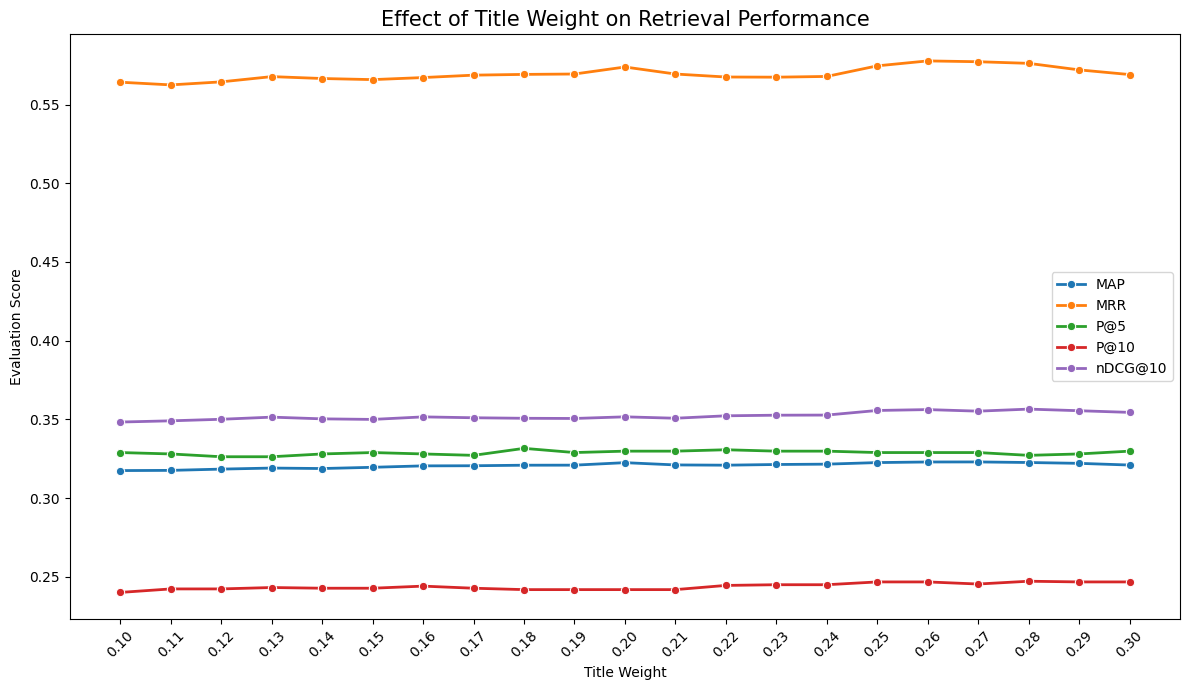

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
metrics = ["MAP", "MRR", "P@5", "P@10", "nDCG@10"]

plt.figure(figsize=(12, 7))

for metric in metrics:
    sns.lineplot(
        data=evaluation_table,
        x="Title Weight",
        y=metric,
        marker="o",
        linewidth=2,
        label=metric
    )

plt.title(
    "Effect of Title Weight on Retrieval Performance",
    fontsize=15
)

plt.xlabel("Title Weight")
plt.ylabel("Evaluation Score")

plt.xticks(
    evaluation_table["Title Weight"],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()


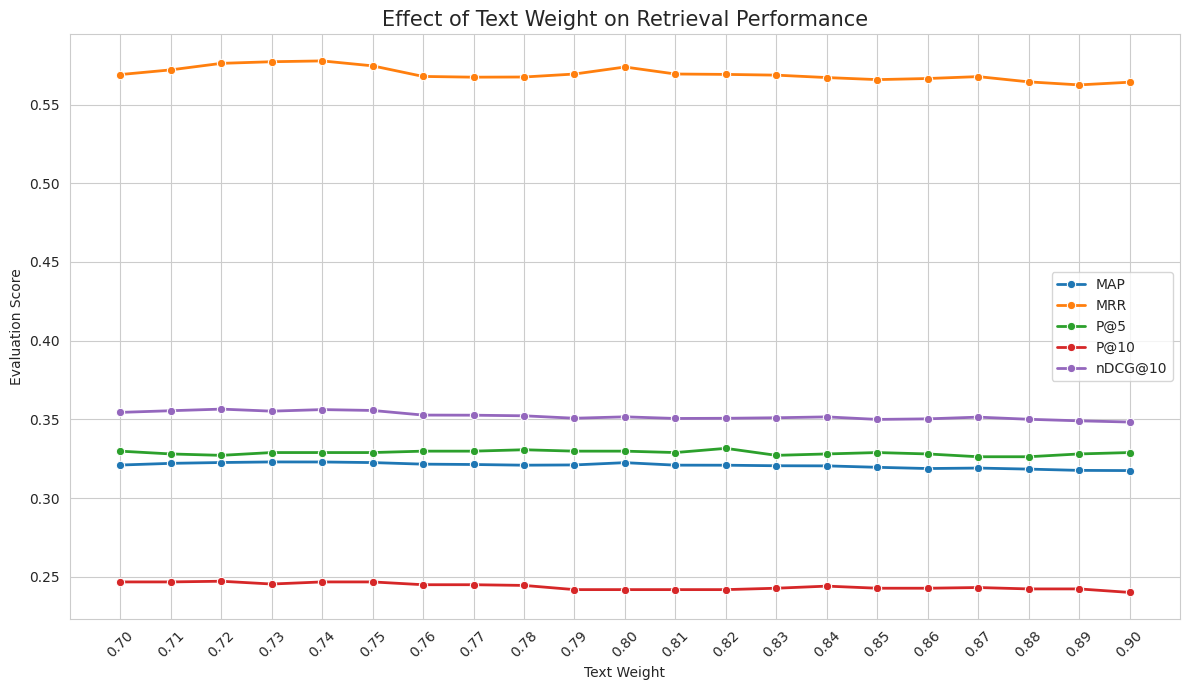

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
metrics = ["MAP", "MRR", "P@5", "P@10", "nDCG@10"]

plt.figure(figsize=(12, 7))

for metric in metrics:
    sns.lineplot(
        data=evaluation_table,
        x="Text Weight",
        y=metric,
        marker="o",
        linewidth=2,
        label=metric
    )

plt.title(
    "Effect of Text Weight on Retrieval Performance",
    fontsize=15
)

plt.xlabel("Text Weight")
plt.ylabel("Evaluation Score")

plt.xticks(
    evaluation_table["Text Weight"],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()


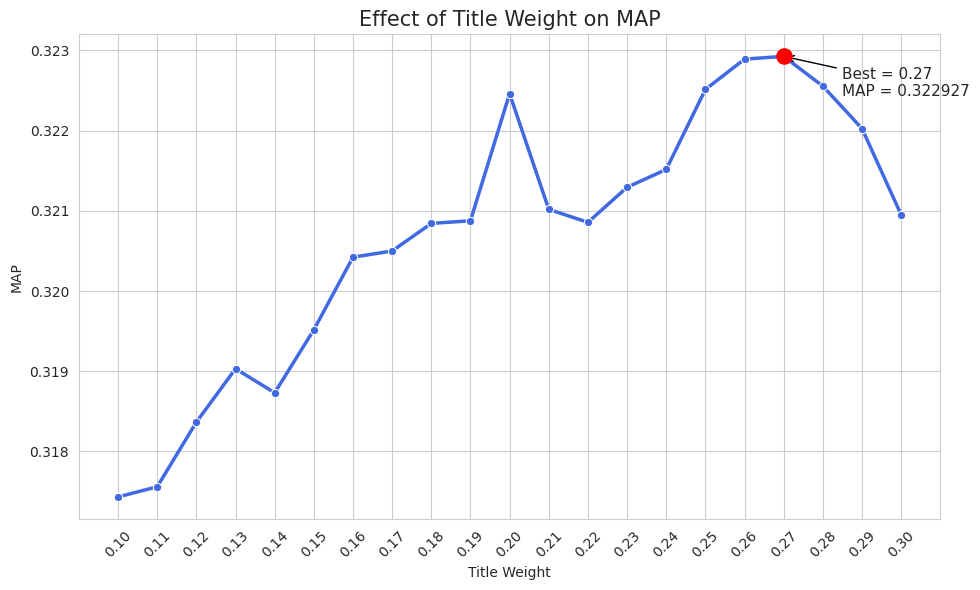

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=evaluation_table,
    x="Title Weight",
    y="MAP",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

# Find best MAP
best_idx = evaluation_table["MAP"].idxmax()
best_weight = evaluation_table.loc[best_idx, "Title Weight"]
best_map = evaluation_table.loc[best_idx, "MAP"]

# Highlight best point
plt.scatter(
    best_weight,
    best_map,
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    f"Best = {best_weight:.2f}\nMAP = {best_map:.6f}",
    xy=(best_weight, best_map),
    xytext=(best_weight + 0.015, best_map - 0.0005),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

plt.title("Effect of Title Weight on MAP", fontsize=15)
plt.xlabel("Title Weight")
plt.ylabel("MAP")
plt.xticks(evaluation_table["Title Weight"], rotation=45)
plt.tight_layout()
plt.show()


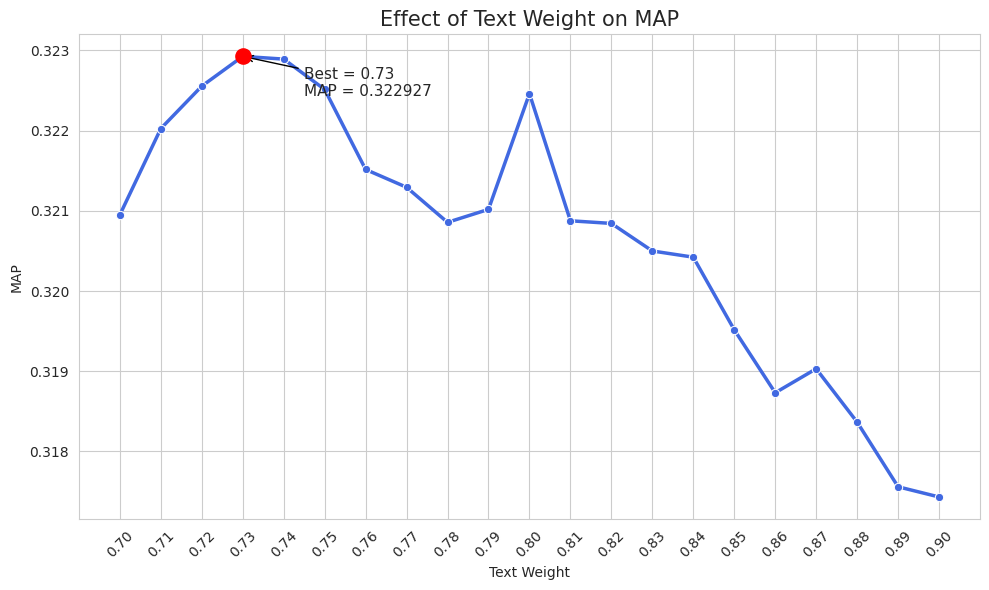

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=evaluation_table,
    x="Text Weight",
    y="MAP",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

# Find best MAP
best_idx = evaluation_table["MAP"].idxmax()
best_weight = evaluation_table.loc[best_idx, "Text Weight"]
best_map = evaluation_table.loc[best_idx, "MAP"]

# Highlight best point
plt.scatter(
    best_weight,
    best_map,
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    f"Best = {best_weight:.2f}\nMAP = {best_map:.6f}",
    xy=(best_weight, best_map),
    xytext=(best_weight + 0.015, best_map - 0.0005),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

plt.title("Effect of Text Weight on MAP", fontsize=15)
plt.xlabel("Text Weight")
plt.ylabel("MAP")
plt.xticks(evaluation_table["Text Weight"], rotation=45)
plt.tight_layout()
plt.show()
